# 2 · Distributions

**Analytical question:** what is the shape, centre and spread of a single
variable — and how does that differ from group to group?

## Charts in this notebook

| Function | Level | Dataset | In one line |
|---|---|---|---|
| `histplot` | axes | penguins | binned counts: the classic histogram |
| `kdeplot` | axes | penguins / california_housing | a smooth density estimate (1-D or 2-D) |
| `ecdfplot` | axes | penguins | the empirical cumulative distribution — no bins, no smoothing |
| `rugplot` | axes | penguins | tick marks for individual observations, layered under another plot |
| `displot` | figure | tips | any of the above, faceted across subsets |

**Method:** one minimal, idiomatic example per function (`kdeplot` gets a 1-D and
a 2-D example). Each ends by saving a PNG to `images/`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from load_data import load_data

sns.set_theme(style="whitegrid")

penguins = sns.load_dataset("penguins")
tips = sns.load_dataset("tips")
housing = load_data("california_housing")

## `histplot`

Axes-level. Splits the range into bins and counts how many observations land in
each — the default first look at a distribution's shape.

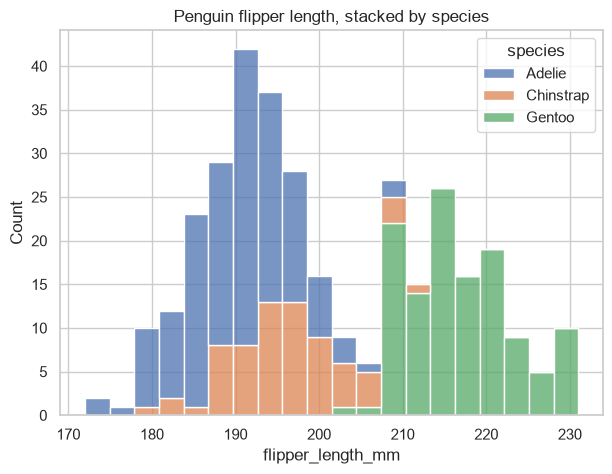

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(
    data=penguins,
    x="flipper_length_mm",
    hue="species", multiple="stack",
    bins=20, ax=ax,
)
ax.set_title("Penguin flipper length, stacked by species")
fig.savefig("images/2_histplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Showing where the mass of a single variable sits: centre, spread, skew, multiple modes, gaps.
- `bins` / `binwidth` set the resolution — too few hides structure, too many shows noise.
- Comparing groups with `hue` + `multiple=`: `"layer"` (translucent overlay), `"stack"` (as here), `"dodge"`, `"fill"` (100 % composition).
- `stat="density"` or `"probability"` when groups differ in size; `element="step"` when several curves overlap.
- **Not** for tiny samples, where the bin choice drives the picture — use `ecdfplot` or a `stripplot` instead.

[`histplot` docs](https://seaborn.pydata.org/generated/seaborn.histplot.html)

## `kdeplot`

Axes-level. Places a smooth "bump" on each observation and adds them up into a
continuous density curve — no bin edges. Pass `y` as well and it becomes a 2-D
density with contours.

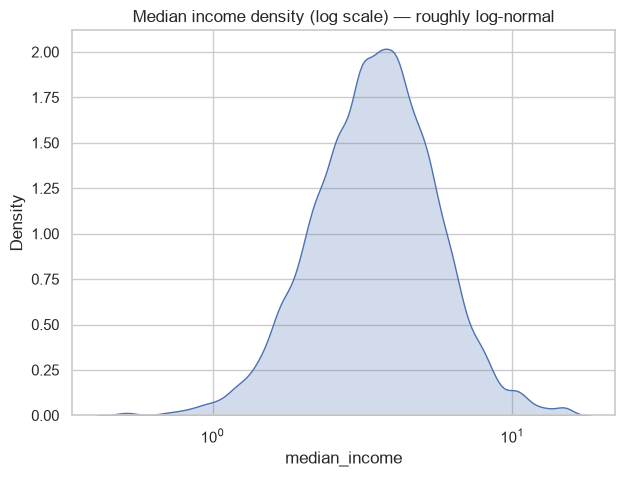

In [3]:
# 1-D: one skewed variable, on a log scale
fig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(data=housing, x="median_income", log_scale=True, fill=True, ax=ax)
ax.set_title("Median income density (log scale) — roughly log-normal")
fig.savefig("images/2_kdeplot_1d.png", dpi=150, bbox_inches="tight")

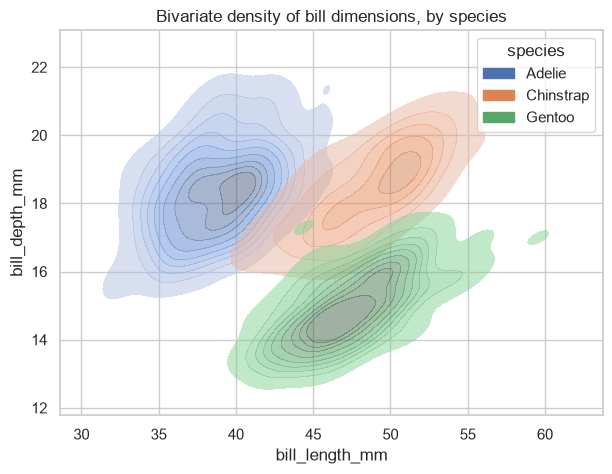

In [4]:
# 2-D: joint density of two variables, one filled set of contours per group
fig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm",
    hue="species", fill=True, alpha=0.5,
    ax=ax,
)
ax.set_title("Bivariate density of bill dimensions, by species")
fig.savefig("images/2_kdeplot_2d.png", dpi=150, bbox_inches="tight")

**Best for**

- A smooth stand-in for the histogram that is easy to overlay for several groups.
- 2-D (`x` **and** `y`): contours show where a joint distribution concentrates without the clutter of a scatter.
- `bw_adjust` tunes the smoothing; `log_scale=True` handles skew; `common_norm=False` makes each group's curve integrate to 1 on its own.
- **Not** for bounded or spiky data — the smoothing bleeds past hard limits (density below zero for a non-negative quantity) and can invent or flatten modes. Fall back to `histplot` / `ecdfplot` then.

[`kdeplot` docs](https://seaborn.pydata.org/generated/seaborn.kdeplot.html)

## `ecdfplot`

Axes-level. For every value on the x-axis, plots the fraction of observations
less than or equal to it. No bins, no smoothing, nothing to tune.

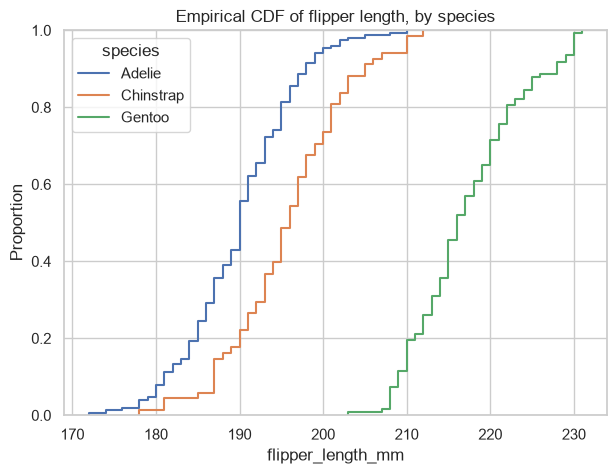

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.ecdfplot(data=penguins, x="flipper_length_mm", hue="species", ax=ax)
ax.set_title("Empirical CDF of flipper length, by species")
fig.savefig("images/2_ecdfplot.png", dpi=150, bbox_inches="tight")

**Best for**

- The least distorting view of a distribution — every observation is drawn exactly, so it is reliable even for small samples.
- Reading percentiles straight off the y-axis (0.5 → median), and comparing groups by the gap between curves.
- Spotting where two groups diverge: parallel curves = a shift, crossing curves = a difference in spread.
- **Not** the most intuitive for an audience raised on histograms — peaks and gaps appear as changes in slope, not bumps.

[`ecdfplot` docs](https://seaborn.pydata.org/generated/seaborn.ecdfplot.html)

## `rugplot`

Axes-level. Draws one short tick per observation along an axis. Almost always a
layer *under* another plot rather than a chart on its own.

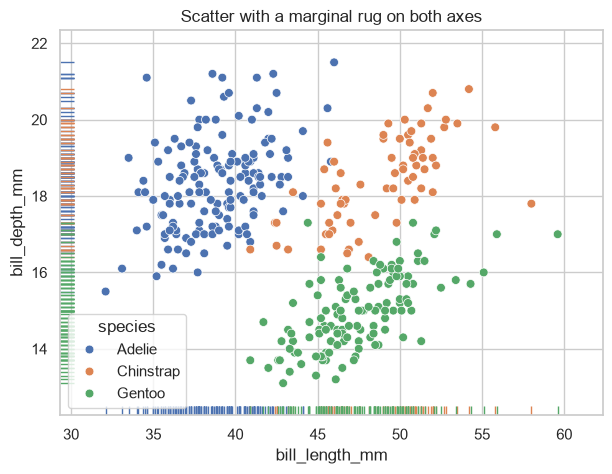

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=penguins, x="bill_length_mm", y="bill_depth_mm",
    hue="species", s=40, ax=ax,
)
sns.rugplot(
    data=penguins, x="bill_length_mm", y="bill_depth_mm",
    hue="species", legend=False, ax=ax,
)
ax.set_title("Scatter with a marginal rug on both axes")
fig.savefig("images/2_rugplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Putting the raw observations back under a summary (a KDE, a regression, a scatter) so the reader sees sample size and clustering.
- A lightweight marginal that needs no extra panel.
- **Not** a standalone chart, and useless once N is large — the ticks merge into a solid bar. Use `alpha=`, `height=`, or a real marginal histogram (`jointplot`, `displot(..., rug=True)`) instead.

[`rugplot` docs](https://seaborn.pydata.org/generated/seaborn.rugplot.html)

## `displot`

Figure-level. The faceting front-end to the whole family: `kind="hist"`
(default), `"kde"` or `"ecdf"`, plus `row` / `col` and a managed legend.

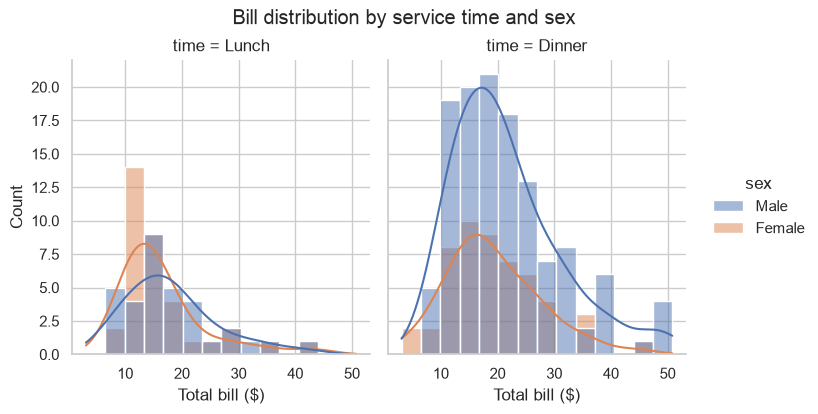

In [7]:
g = sns.displot(
    data=tips,
    x="total_bill",
    col="time", hue="sex",
    kind="hist", kde=True,
    height=4, aspect=0.9,
)
g.set_axis_labels("Total bill ($)", "Count")
g.figure.suptitle("Bill distribution by service time and sex", y=1.03)
g.savefig("images/2_displot.png", dpi=150, bbox_inches="tight")

**Best for**

- "How does this distribution change across subgroups?" — `row` / `col` split the data into a grid, one distribution per panel.
- Switching representation without switching function: `kind="hist" | "kde" | "ecdf"`, with `kde=True` / `rug=True` to layer.
- Figure-level housekeeping: shared axes, one legend, consistent binning across panels.
- **Not** for placing a distribution on a specific `Axes` in a hand-built figure — call `histplot` / `kdeplot` / `ecdfplot` directly.

[`displot` docs](https://seaborn.pydata.org/generated/seaborn.displot.html)